---
title: "Extreme Heat Risk in Pergamino"
subtitle: "Climate projections, current heat patterns, and policy recommendations"
author: "Nissim Lebovits"
date: "2025-11-26"
---

## Introduction

This cookbook demonstrates how to assess extreme heat risk in a city using open data. We apply the climate risk framework from Chapter 3 (exposure, vulnerability, hazard) to extreme heat in Pergamino, a city of approximately 100,000 people in Buenos Aires Province, Argentina.

You will learn how to:

- Query CMIP6 climate projections to understand how extreme heat days will change
- Calculate land surface temperature from Landsat imagery to identify current hotspots
- Map population exposure and vulnerability using census data
- Connect findings to policy recommendations using robust decision-making principles

The analysis concludes with five policy recommendations that work across multiple climate scenarios—an application of the robust decision-making framework from Chapter 4.

## Setup

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import duckdb
import requests
from io import BytesIO
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=xr.SerializationWarning)

# CRS settings
USE_CRS = "EPSG:5346"  # POSGAR 2007 / Argentina 3 (Buenos Aires)
WGS84_CRS = "EPSG:4326"

# Visualization defaults
DEFAULT_FIGSIZE = (10, 8)
plt.rcParams["figure.dpi"] = 100

## Study Area

We load Pergamino's municipal boundary from Argentina's National Geographic Institute (IGN) WFS service, then retrieve urban classification and neighborhood boundaries from Pergamino's local spatial data infrastructure.

In [2]:
# Load Pergamino boundary from IGN WFS
ign_wfs_url = "https://wms.ign.gob.ar/geoserver/ign/ows"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "ign:departamento",
    "outputFormat": "application/json",
    "CQL_FILTER": "nam='Pergamino'",
}

response = requests.get(ign_wfs_url, params=params)
pergamino = gpd.read_file(BytesIO(response.content))
pergamino = pergamino.to_crs(USE_CRS)

# Get bounding box in WGS84 for queries
bbox_wgs84 = pergamino.to_crs(WGS84_CRS).total_bounds

print("Loaded Pergamino boundary")
print(f"Area: {pergamino.geometry.area.sum() / 1e6:.0f} km²")
print(f"Bounding box (WGS84): {bbox_wgs84}")

Loaded Pergamino boundary
Area: 3009 km²
Bounding box (WGS84): [-60.942796   -34.17645991 -60.138771   -33.54020044]


In [3]:
# Load urban classification from Pergamino WFS
pergamino_wfs_url = "https://ide.pergamino.gob.ar:8443/geoserver/wfs"

params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "publico:aglomerados_urbanos",
    "outputFormat": "application/json",
    "srsname": "EPSG:4326",
}

response = requests.get(pergamino_wfs_url, params=params)
urban_areas = gpd.read_file(BytesIO(response.content))
urban_areas = urban_areas.to_crs(USE_CRS)

print(f"Urban classifications: {urban_areas['clasificacion'].unique()}")
for clase in urban_areas["clasificacion"].unique():
    area = urban_areas[urban_areas["clasificacion"] == clase].geometry.area.sum() / 1e6
    print(f"  {clase}: {area:.1f} km²")

Urban classifications: ['urbana' 'periurbana' 'urbano en ruralidad']
  urbana: 26.2 km²
  periurbana: 10.5 km²
  urbano en ruralidad: 10.8 km²


In [4]:
# Load neighborhood boundaries from Pergamino WFS
params = {
    "service": "WFS",
    "version": "2.0.0",
    "request": "GetFeature",
    "typename": "publico:barrios",
    "outputFormat": "application/json",
    "srsname": "EPSG:4326",
}

response = requests.get(pergamino_wfs_url, params=params)
barrios = gpd.read_file(BytesIO(response.content))
barrios = barrios.to_crs(USE_CRS)

print(f"Loaded {len(barrios)} neighborhoods")

Loaded 45 neighborhoods


/tmp/user/1000/ipykernel_110143/1600420605.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="Classification")
/tmp/user/1000/ipykernel_110143/1600420605.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Classification")


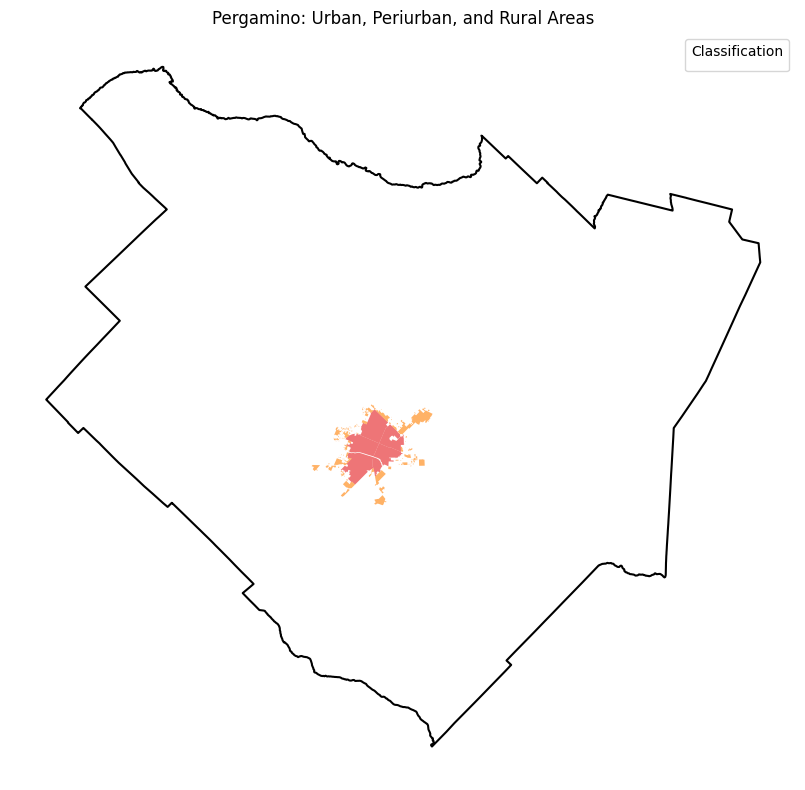

In [5]:
# | code-fold: true
# | code-summary: "Show visualization code"

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

pergamino.plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1.5)

colors = {"urbana": "#e41a1c", "periurbana": "#ff7f00", "rural": "#4daf4a"}
for clase, color in colors.items():
    subset = urban_areas[urban_areas["clasificacion"] == clase]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=color, edgecolor="none", alpha=0.6, label=clase)

ax.legend(title="Classification")
ax.set_title("Pergamino: Urban, Periurban, and Rural Areas")
ax.axis("off")
plt.tight_layout()
plt.show()

## Climate Projections: How Hot Will It Get?

We query CMIP6 climate projections from the Copernicus Climate Data Store to understand how extreme heat days will change over the coming decades. We use the variable "days with maximum temperature above 35°C" as our indicator of extreme heat.

::: {.callout-note}
## Understanding SSP Scenarios

The Shared Socioeconomic Pathways (SSPs) represent different possible futures based on societal choices about emissions, development, and climate policy:

- **SSP1-2.6 (Low emissions)**: Aggressive emissions reductions, limiting warming to ~1.8°C by 2100
- **SSP2-4.5 (Intermediate)**: Moderate mitigation efforts, ~2.7°C warming by 2100
- **SSP5-8.5 (High emissions)**: Continued fossil fuel dependence, ~4.4°C warming by 2100

We analyze all three scenarios because we cannot predict which path society will take. Robust planning means preparing for multiple futures.
:::

In [6]:
import cdsapi
import zipfile

# Define experiments to download
experiments = {
    "historical": {"experiment": "historical", "period": None},
    "ssp1_2_6": {"experiment": "ssp1_2_6", "period": "2015-2100"},
    "ssp2_4_5": {"experiment": "ssp2_4_5", "period": "2015-2100"},
    "ssp5_8_5": {"experiment": "ssp5_8_5", "period": "2015-2100"},
}

c = cdsapi.Client()

# Get center point for Pergamino
center_lon = (bbox_wgs84[0] + bbox_wgs84[2]) / 2
center_lat = (bbox_wgs84[1] + bbox_wgs84[3]) / 2
print(f"Query center: {center_lat:.4f}, {center_lon:.4f}")

# Dictionary to store processed data
all_data = {}

for exp_name, exp_config in experiments.items():
    zip_file = f"ipcc_atlas_{exp_name}.zip"
    extract_dir = f"ipcc_{exp_name}_data"

    # Download if not exists
    if not Path(zip_file).exists():
        print(f"Downloading {exp_name}...")
        try:
            request = {
                "origin": "cmip6",
                "experiment": exp_config["experiment"],
                "domain": "global",
                "variable": "monthly_count_of_days_with_maximum_temperature_above_35_c",
            }
            if exp_config["period"]:
                request["period"] = exp_config["period"]

            c.retrieve("projections-climate-atlas", request, zip_file)
        except Exception as e:
            print(f"Error downloading {exp_name}: {e}")
            continue
    else:
        print(f"Using cached {exp_name}")

    # Extract and process
    try:
        if not Path(extract_dir).exists():
            with zipfile.ZipFile(zip_file, "r") as zip_ref:
                zip_ref.extractall(extract_dir)

        # Find the netCDF file
        nc_files = list(Path(extract_dir).glob("*.nc"))
        if not nc_files:
            print(f"No NC file found for {exp_name}")
            continue

        ds = xr.open_dataset(nc_files[0])

        # Extract data for Pergamino's location
        # The variable is 'tx35' (days with max temp > 35C)
        # Longitude is in -180 to 180 format, no conversion needed
        point_data = ds["tx35"].sel(lon=center_lon, lat=center_lat, method="nearest")

        # Average across ensemble members (different climate models)
        point_mean = point_data.mean(dim="member")

        # Sum monthly values to get annual totals
        annual_data = point_mean.groupby("time.year").sum()

        # Store as DataFrame
        df = pd.DataFrame(
            {"year": annual_data.year.values, "days_over_35C": annual_data.values}
        )
        all_data[exp_name] = df

        print(
            f"  {exp_name}: {len(df)} years, mean={df['days_over_35C'].mean():.1f} days/year"
        )

        ds.close()

    except Exception as e:
        print(f"Error processing {exp_name}: {e}")

Query center: -33.8583, -60.5408
Using cached historical
  historical: 165 years, mean=26.5 days/year
Using cached ssp1_2_6
  ssp1_2_6: 86 years, mean=49.8 days/year
Using cached ssp2_4_5
  ssp2_4_5: 86 years, mean=53.1 days/year
Using cached ssp5_8_5
  ssp5_8_5: 86 years, mean=62.2 days/year


In [7]:
# Calculate key statistics
historical_1950 = all_data["historical"][all_data["historical"]["year"] >= 1950].copy()
hist_baseline = historical_1950["days_over_35C"].mean()

print("=" * 60)
print("HISTORICAL BASELINE (1950-2014)")
print("=" * 60)
print(f"Mean days >35°C per year: {hist_baseline:.1f}")
print(f"Standard deviation: {historical_1950['days_over_35C'].std():.1f}")
print(
    f"Range: {historical_1950['days_over_35C'].min():.0f} - {historical_1950['days_over_35C'].max():.0f}"
)
print()

# Calculate projections for key time periods
print("PROJECTIONS BY TIME PERIOD")
print("-" * 60)

time_periods = [
    ("2020-2050", 2020, 2050),
    ("2050-2070", 2050, 2070),
    ("2070-2100", 2070, 2100),
]

labels = {
    "ssp1_2_6": "SSP1-2.6 (Low)",
    "ssp2_4_5": "SSP2-4.5 (Intermediate)",
    "ssp5_8_5": "SSP5-8.5 (High)",
}

for period_name, start, end in time_periods:
    print(f"\n{period_name}:")
    for scenario in ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]:
        data = all_data[scenario]
        period_data = data[(data["year"] >= start) & (data["year"] <= end)]
        period_mean = period_data["days_over_35C"].mean()
        change = period_mean - hist_baseline
        pct_change = (change / hist_baseline) * 100
        print(
            f"  {labels[scenario]}: {period_mean:.1f} days/year (+{change:.1f}, {pct_change:+.0f}%)"
        )

HISTORICAL BASELINE (1950-2014)
Mean days >35°C per year: 38.7
Standard deviation: 2.6
Range: 33 - 44

PROJECTIONS BY TIME PERIOD
------------------------------------------------------------

2020-2050:
  SSP1-2.6 (Low): 48.4 days/year (+9.7, +25%)
  SSP2-4.5 (Intermediate): 48.0 days/year (+9.3, +24%)
  SSP5-8.5 (High): 49.3 days/year (+10.7, +28%)

2050-2070:
  SSP1-2.6 (Low): 51.6 days/year (+12.9, +33%)
  SSP2-4.5 (Intermediate): 54.3 days/year (+15.6, +40%)
  SSP5-8.5 (High): 61.3 days/year (+22.7, +59%)

2070-2100:
  SSP1-2.6 (Low): 51.0 days/year (+12.3, +32%)
  SSP2-4.5 (Intermediate): 58.8 days/year (+20.1, +52%)
  SSP5-8.5 (High): 78.4 days/year (+39.8, +103%)


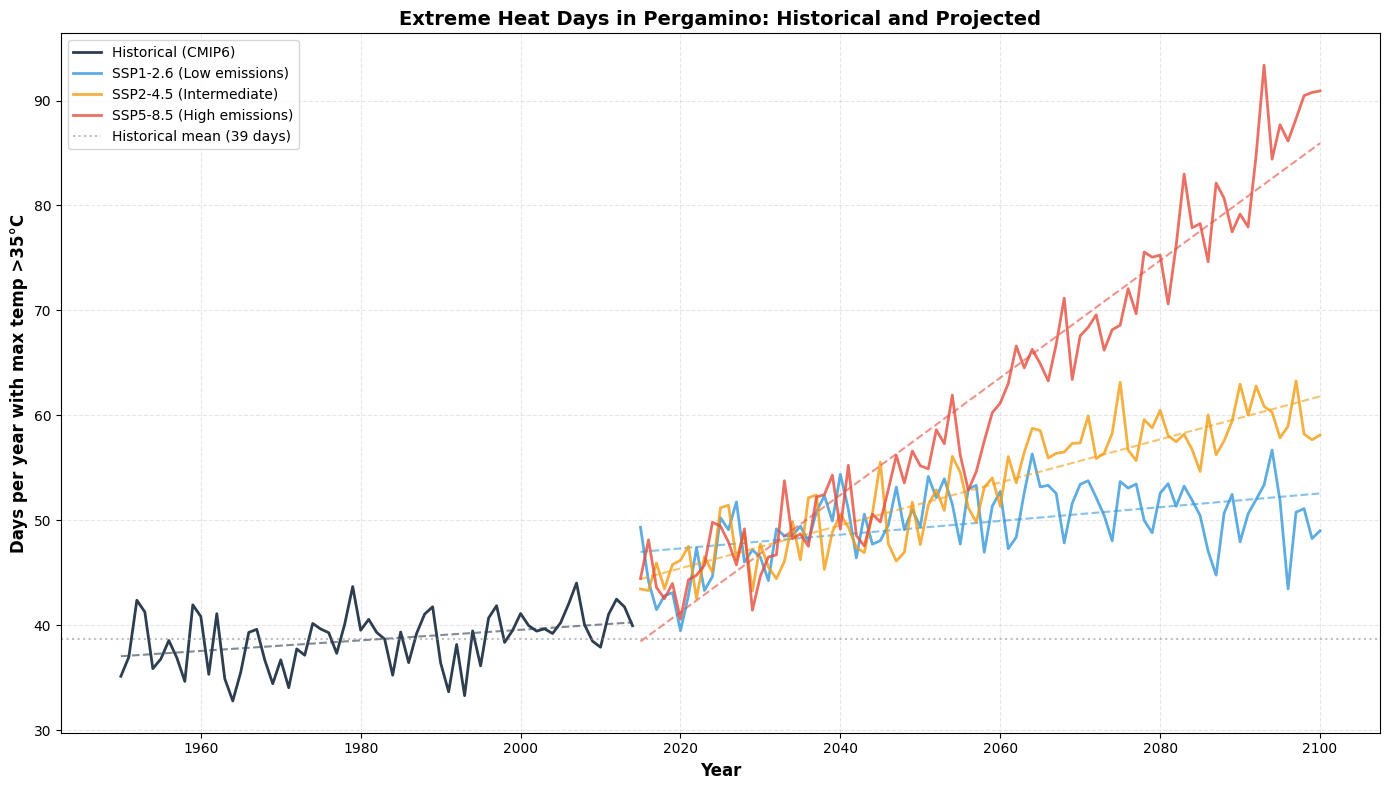

In [8]:
# | code-fold: true
# | code-summary: "Show visualization code"

from scipy import stats

fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    "historical": "#2c3e50",
    "ssp1_2_6": "#3498db",
    "ssp2_4_5": "#f39c12",
    "ssp5_8_5": "#e74c3c",
}

labels_full = {
    "historical": "Historical (CMIP6)",
    "ssp1_2_6": "SSP1-2.6 (Low emissions)",
    "ssp2_4_5": "SSP2-4.5 (Intermediate)",
    "ssp5_8_5": "SSP5-8.5 (High emissions)",
}

# Plot historical
ax.plot(
    historical_1950["year"],
    historical_1950["days_over_35C"],
    linewidth=2,
    color=colors["historical"],
    label=labels_full["historical"],
)

# Add historical trend line
z_hist = np.polyfit(historical_1950["year"], historical_1950["days_over_35C"], 1)
p_hist = np.poly1d(z_hist)
ax.plot(
    historical_1950["year"],
    p_hist(historical_1950["year"]),
    "--",
    linewidth=1.5,
    color=colors["historical"],
    alpha=0.6,
)

# Plot projections
for scenario in ["ssp1_2_6", "ssp2_4_5", "ssp5_8_5"]:
    data = all_data[scenario]
    ax.plot(
        data["year"],
        data["days_over_35C"],
        linewidth=2,
        color=colors[scenario],
        label=labels_full[scenario],
        alpha=0.8,
    )

    # Add trend line
    z = np.polyfit(data["year"], data["days_over_35C"], 1)
    p = np.poly1d(z)
    ax.plot(
        data["year"],
        p(data["year"]),
        "--",
        linewidth=1.5,
        color=colors[scenario],
        alpha=0.6,
    )

ax.axhline(
    y=hist_baseline,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"Historical mean ({hist_baseline:.0f} days)",
)
ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_ylabel("Days per year with max temp >35°C", fontsize=12, fontweight="bold")
ax.set_title(
    "Extreme Heat Days in Pergamino: Historical and Projected",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

The projections show that under current trajectories (SSP2-4.5), Pergamino can expect:

- **By 2050**: ~48 days/year >35°C (+24% from baseline)
- **By 2070**: ~54 days/year (+40%)
- **By 2100**: ~59 days/year (+52%)

Even under aggressive emissions reductions (SSP1-2.6), the city will experience increased heat stress. This is why we need to plan for multiple scenarios rather than a single "most likely" future.

## Current Heat Patterns: Where Is It Hottest Now?

To identify current heat hotspots, we calculate Land Surface Temperature (LST) from Landsat satellite imagery. We compute the maximum LST over the past 5 years to identify persistently hot areas.

::: {.callout-important}
## LST vs. Air Temperature

Land Surface Temperature measures how hot the ground surface is, not air temperature. LST can exceed air temperature by 20°C or more on hot days. We use LST as a **relative indicator** to identify which areas are hotter than others, not to predict human heat exposure directly. The P75 threshold identifies the top quartile of temperatures within Pergamino—these are the relative hotspots regardless of the absolute values.
:::

In [9]:
import planetary_computer
import pystac_client
from odc.stac import stac_load, configure_rio
from dask.distributed import Client, LocalCluster
from dask.diagnostics import ProgressBar

# Connect to Planetary Computer
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Set up Dask cluster for parallel processing
cluster = LocalCluster(
    processes=True,
    n_workers=4,
    threads_per_worker=2,
    memory_limit="4GB",
    dashboard_address=":0",
)
client = Client(cluster)
configure_rio(cloud_defaults=True, client=client)

# Query Landsat for last 5 years, summer months only (Dec-Feb)
datetime = "2020-01-01/2025-01-01"
cloudy_less_than = 20

query = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox_wgs84,
    datetime=datetime,
    query={"eo:cloud_cover": {"lt": cloudy_less_than}},
)

items = list(query.items())
print(f"Found {len(items)} Landsat scenes")

Found 488 Landsat scenes


In [10]:
# Check for cached LST file
lst_tif_path = Path("LST_max_pergamino.tif")

if lst_tif_path.exists():
    print(f"Loading cached LST from {lst_tif_path}")
    LST_max = rio.open_rasterio(lst_tif_path)
    if len(LST_max.dims) > 2:
        LST_max = LST_max.squeeze()
else:
    print("Computing LST from Landsat imagery...")

    # Load thermal band and QA
    crs = "epsg:3857"
    yy = stac_load(
        items,
        bands=("lwir11", "qa_pixel"),
        crs=crs,
        resolution=30,
        chunks={"time": 10},
        groupby="landsat:scene_id",
        bbox=bbox_wgs84,
    )

    # Cloud mask function
    def create_cloud_mask(qa_band):
        """Mask clouds and cloud shadows (bits 3 and 4)"""
        cloud_mask = (qa_band & 0b11000) == 0
        return cloud_mask

    # Apply cloud mask
    yy_masked = yy.where(create_cloud_mask(yy.qa_pixel))

    # Convert to LST in Celsius
    LST_kelvin = yy_masked["lwir11"] * 0.00341802 + 149.0
    LST_celsius = LST_kelvin - 273.15

    # Calculate maximum LST per pixel
    LST_max_lazy = LST_celsius.max(dim="time")

    print("Computing (this may take a few minutes)...")
    with ProgressBar():
        LST_max = LST_max_lazy.compute()

    # Save to file
    LST_max.rio.to_raster(lst_tif_path)
    print(f"Saved to {lst_tif_path}")

# Basic stats
print("\nLST Statistics:")
print(f"  Min: {float(LST_max.min()):.1f}°C")
print(f"  Max: {float(LST_max.max()):.1f}°C")
print(f"  Mean: {float(LST_max.mean()):.1f}°C")
print(f"  P75 (hotspot threshold): {float(LST_max.quantile(0.75)):.1f}°C")

Computing LST from Landsat imagery...
Computing (this may take a few minutes)...


/home/nissim/Documents/dev/datos-escala-humana/.venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Saved to LST_max_pergamino.tif

LST Statistics:
  Min: 33.7°C
  Max: 65.4°C
  Mean: 52.9°C
  P75 (hotspot threshold): 55.2°C


In [11]:
# Define hotspot threshold as P75 (top quartile)
hotspot_threshold = float(LST_max.quantile(0.75))
hotspot_mask = LST_max > hotspot_threshold

# Calculate hotspot area
pixel_area_m2 = abs(LST_max.rio.resolution()[0] * LST_max.rio.resolution()[1])
hotspot_area_km2 = (hotspot_mask.sum().values * pixel_area_m2) / 1e6

print(f"Hotspot threshold (P75): {hotspot_threshold:.1f}°C")
print(f"Hotspot area: {hotspot_area_km2:.1f} km²")

Hotspot threshold (P75): 55.2°C
Hotspot area: 1910.0 km²


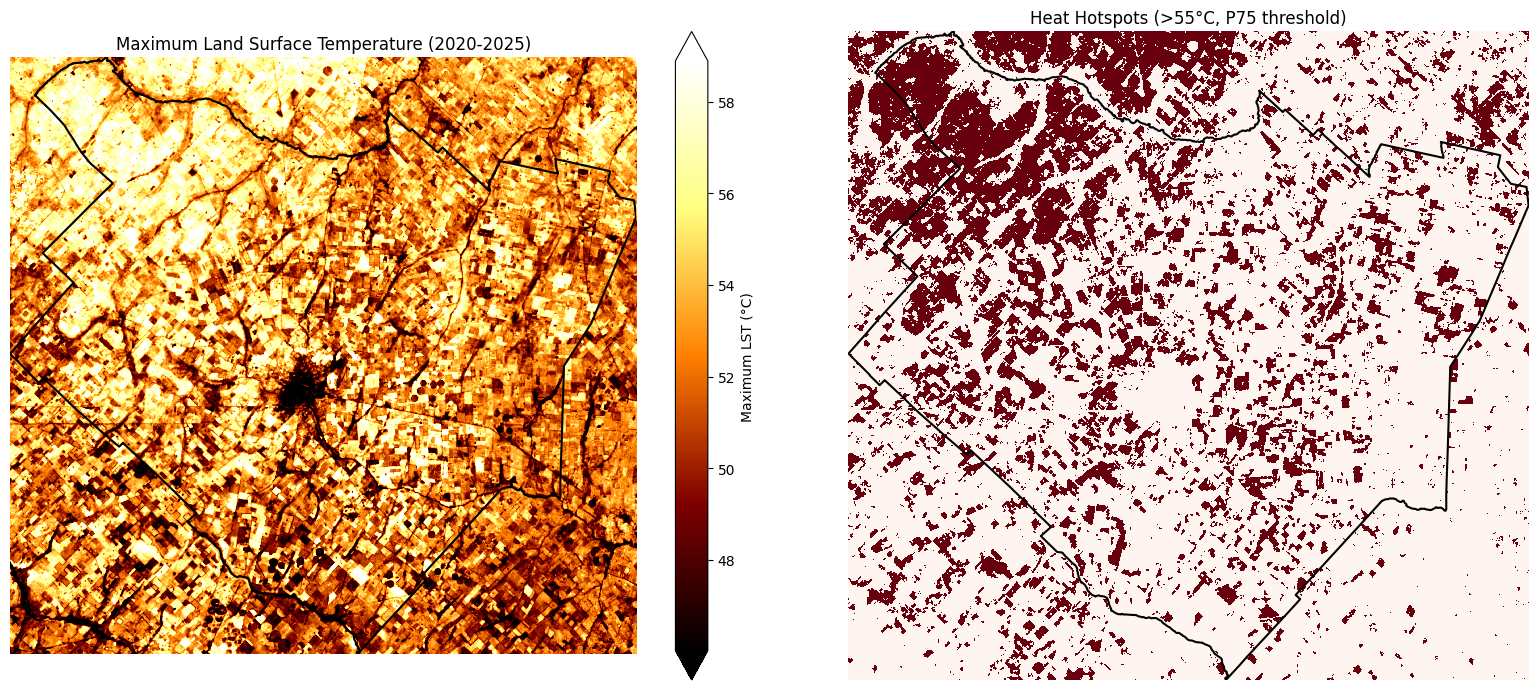

In [12]:
# | code-fold: true
# | code-summary: "Show visualization code"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: LST values
LST_max.plot.imshow(
    ax=axes[0],
    cmap="afmhot",
    cbar_kwargs={"label": "Maximum LST (°C)"},
    robust=True,
)
pergamino.to_crs(LST_max.rio.crs).plot(
    ax=axes[0], facecolor="none", edgecolor="black", linewidth=1.5
)
axes[0].set_title("Maximum Land Surface Temperature (2020-2025)")
axes[0].axis("off")

# Right: Hotspots
hotspot_mask.plot.imshow(
    ax=axes[1],
    cmap="Reds",
    add_colorbar=False,
)
pergamino.to_crs(LST_max.rio.crs).plot(
    ax=axes[1], facecolor="none", edgecolor="black", linewidth=1.5
)
axes[1].set_title(f"Heat Hotspots (>{hotspot_threshold:.0f}°C, P75 threshold)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### LST by Urban Classification

We calculate average LST for each urban classification to understand the spatial pattern of heat.

In [13]:
from rasterstats import zonal_stats

# Reproject urban areas to match LST CRS
urban_areas_lst_crs = urban_areas.to_crs(LST_max.rio.crs)

# Calculate zonal statistics
lst_values = LST_max.values
lst_transform = LST_max.rio.transform()

results = []
for idx, row in urban_areas_lst_crs.iterrows():
    stats = zonal_stats(
        [row.geometry],
        lst_values,
        affine=lst_transform,
        stats=["mean", "std", "min", "max", "percentile_75"],
        nodata=np.nan,
    )[0]

    results.append(
        {
            "classification": row["clasificacion"],
            "mean_lst": stats["mean"],
            "std_lst": stats["std"],
            "min_lst": stats["min"],
            "max_lst": stats["max"],
            "p75_lst": stats["percentile_75"],
        }
    )

lst_by_class = pd.DataFrame(results)
lst_summary = lst_by_class.groupby("classification").mean().round(1)

print("LST by Urban Classification:")
print(lst_summary)

LST by Urban Classification:
                     mean_lst  std_lst  min_lst  max_lst  p75_lst
classification                                                   
periurbana               51.0      0.7     49.6     52.6     51.5
urbana                   46.2      2.3     41.1     53.6     47.7
urbano en ruralidad      49.0      1.6     45.8     53.9     50.0


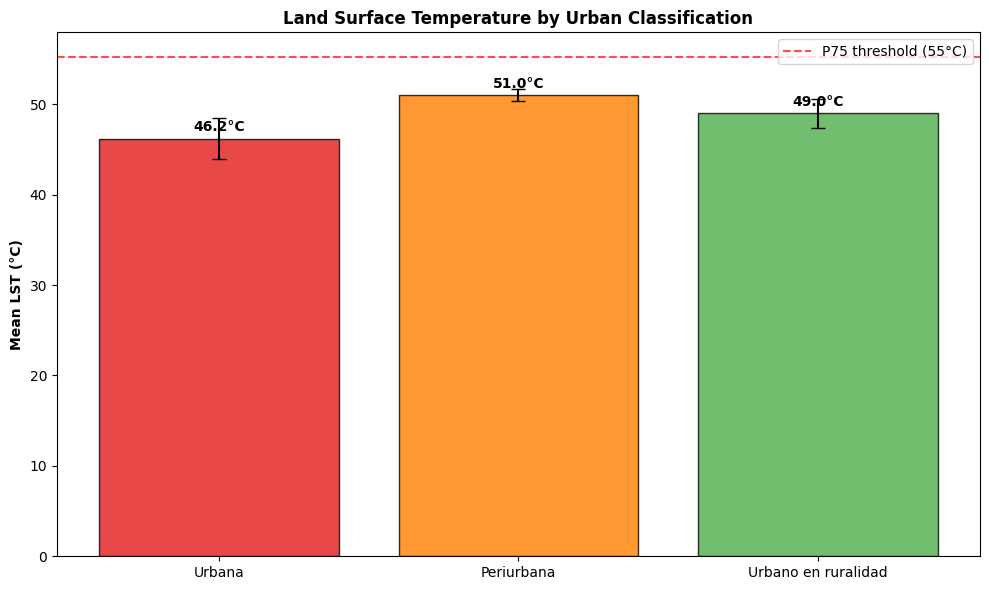

In [15]:
# | code-fold: true
# | code-summary: "Show visualization code"

fig, ax = plt.subplots(figsize=(10, 6))

classes = ["urbana", "periurbana", "urbano en ruralidad"]
colors_bar = ["#e41a1c", "#ff7f00", "#4daf4a"]

x = np.arange(len(classes))
means = [lst_summary.loc[c, "mean_lst"] for c in classes]
stds = [lst_summary.loc[c, "std_lst"] for c in classes]

bars = ax.bar(x, means, color=colors_bar, alpha=0.8, edgecolor="black")
ax.errorbar(x, means, yerr=stds, fmt="none", color="black", capsize=5)

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in classes])
ax.set_ylabel("Mean LST (°C)", fontweight="bold")
ax.set_title("Land Surface Temperature by Urban Classification", fontweight="bold")
ax.axhline(
    y=hotspot_threshold,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"P75 threshold ({hotspot_threshold:.0f}°C)",
)
ax.legend()

# Add value labels
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{mean:.1f}°C",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

A key finding: **periurban areas are the hottest**, while the urban core is cooler. This pattern reflects the presence of more tree cover and building shade in established urban areas, while periurban zones often have less vegetation and more exposed surfaces.

## Exposure: Who Lives in Hot Areas?

We use three complementary data sources to measure population exposure:

1. **GHSL (Global Human Settlement Layer)**: Gridded population at 100m resolution
2. **Census 2022**: Official population by census tract
3. **Building footprints**: Structural exposure indicator

In [16]:
# GHSL Population (2025, 100m)
ghsl_url = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/GHSL/GHS_POP_GLOBE_R2023A/GHS_POP_E2025_GLOBE_R2023A_54009_100/V1-0/tiles/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R14_C13.zip"

# Virtual path to read from remote ZIP
vsi_path = (
    f"/vsizip/vsicurl/{ghsl_url}/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R14_C13.tif"
)

ghsl = rio.open_rasterio(vsi_path)

# Clip to study area
aoi_ghsl_crs = urban_areas.to_crs(ghsl.rio.crs).union_all()
ghsl_clipped = ghsl.rio.clip([aoi_ghsl_crs])
ghsl_masked = ghsl_clipped.where(ghsl_clipped > 0)

total_pop_ghsl = float(ghsl_masked.sum())
print(f"GHSL estimated population: {total_pop_ghsl:,.0f}")

GHSL estimated population: 113,636


In [17]:
# Census population from Source Cooperative
con = duckdb.connect()
for cmd in [
    "INSTALL spatial",
    "LOAD spatial",
    "INSTALL httpfs",
    "LOAD httpfs",
    "SET s3_region='us-east-1'",
    "SET s3_endpoint='data.source.coop'",
    "SET s3_use_ssl=true",
    "SET s3_url_style='path'",
]:
    con.execute(cmd)

# Query census tracts for Pergamino
query = f"""
SELECT
    COD_2022,
    POB_TOT_P,
    ST_AsWKB(geometry) as geometry
FROM 's3://nlebovits/censo-argentino/2022/radios.parquet'
WHERE ST_XMax(geometry) >= {bbox_wgs84[0]}
  AND ST_XMin(geometry) <= {bbox_wgs84[2]}
  AND ST_YMax(geometry) >= {bbox_wgs84[1]}
  AND ST_YMin(geometry) <= {bbox_wgs84[3]}
"""

df = con.execute(query).fetchdf()
df["geometry"] = gpd.GeoSeries.from_wkb(df["geometry"].apply(bytes))
census_tracts = gpd.GeoDataFrame(df, geometry="geometry", crs=WGS84_CRS)
census_tracts = census_tracts.to_crs(USE_CRS)

# Clip to urban areas
census_clipped = gpd.clip(census_tracts, urban_areas.union_all())

total_pop_census = census_clipped["POB_TOT_P"].sum()
print(f"Census population (urban areas): {total_pop_census:,}")
print(f"Census tracts: {len(census_clipped)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Census population (urban areas): 114,472
Census tracts: 193


In [18]:
# Building footprints from Source Cooperative
buildings_file = "buildings_pergamino.parquet"

query = f"""
COPY (
    SELECT *
    FROM 's3://vida/google-microsoft-open-buildings/geoparquet/by_country/country_iso=ARG/ARG.parquet'
    WHERE bbox.xmax >= {bbox_wgs84[0]} AND bbox.xmin <= {bbox_wgs84[2]} AND
          bbox.ymax >= {bbox_wgs84[1]} AND bbox.ymin <= {bbox_wgs84[3]}
) TO '{buildings_file}' (FORMAT PARQUET);
"""
con.execute(query)

buildings_df = pd.read_parquet(buildings_file)
buildings_df["geometry"] = gpd.GeoSeries.from_wkb(buildings_df["geometry"].apply(bytes))
buildings = gpd.GeoDataFrame(buildings_df, geometry="geometry", crs=WGS84_CRS)
buildings = buildings.to_crs(USE_CRS)

# Clip to urban areas
buildings = gpd.clip(buildings, urban_areas.union_all())

total_buildings = len(buildings)
print(f"Total buildings: {total_buildings:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total buildings: 103,371


In [19]:
# Exposure summary
print("=" * 60)
print("EXPOSURE SUMMARY")
print("=" * 60)
print(f"GHSL population estimate: {total_pop_ghsl:,.0f}")
print(f"Census population: {total_pop_census:,}")
print(f"Buildings: {total_buildings:,}")
print(
    f"Difference GHSL vs Census: {((total_pop_ghsl - total_pop_census) / total_pop_census) * 100:+.1f}%"
)

EXPOSURE SUMMARY
GHSL population estimate: 113,636
Census population: 114,472
Buildings: 103,371
Difference GHSL vs Census: -0.7%


### Population in Heat Hotspots

We calculate how many people live in the hottest areas (P75 LST threshold).

In [31]:
from rasterio import features

# Reproject GHSL to match LST
ghsl_lst_crs = ghsl_clipped.rio.reproject(LST_max.rio.crs)
ghsl_aligned = ghsl_lst_crs.rio.reproject_match(LST_max)

# Mask invalid values (nodata and negative)
ghsl_aligned = ghsl_aligned.where(ghsl_aligned > 0, 0)

# Population in hotspots
pop_in_hotspots = float(ghsl_aligned.where(hotspot_mask).sum())
pct_in_hotspots = (pop_in_hotspots / total_pop_ghsl) * 100

print(f"Population in heat hotspots: {pop_in_hotspots:,.0f}")
print(f"Percentage of total: {pct_in_hotspots:.1f}%")

Population in heat hotspots: 798
Percentage of total: 0.7%


In [21]:
# Exposure by urban classification
print("\nExposure by Urban Classification:")
print("-" * 50)

exposure_by_class = []

for clase in ["urbana", "periurbana", "rural"]:
    subset = urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == clase]
    if len(subset) == 0:
        continue

    # Rasterize the classification zone
    class_mask = (
        features.rasterize(
            [(geom, 1) for geom in subset.geometry],
            out_shape=LST_max.shape,
            transform=LST_max.rio.transform(),
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    # Total pop in this class
    total_class = float(ghsl_aligned.where(class_mask).sum())

    # Pop in hotspots within this class
    hotspot_class = float(ghsl_aligned.where(hotspot_mask & class_mask).sum())

    pct = (hotspot_class / total_class * 100) if total_class > 0 else 0

    exposure_by_class.append(
        {
            "classification": clase,
            "total_pop": total_class,
            "pop_in_hotspots": hotspot_class,
            "pct_exposed": pct,
        }
    )

    print(
        f"{clase.capitalize():12} | Total: {total_class:>8,.0f} | Hotspots: {hotspot_class:>6,.0f} ({pct:.1f}%)"
    )

exposure_df = pd.DataFrame(exposure_by_class)


Exposure by Urban Classification:
--------------------------------------------------
Urbana       | Total: 1,401,161 | Hotspots:      0 (0.0%)
Periurbana   | Total: -469,330 | Hotspots: -19,637 (0.0%)


## Vulnerability: Who Is Most at Risk?

We use the IPMH (Índice de Privación Material de los Hogares) from the 2022 census as our vulnerability indicator. This index classifies households by material deprivation—a proxy for capacity to cope with extreme heat.

In [22]:
# Query deprivation data from Source Coop
query = f"""
WITH privacion_data AS (
    SELECT
        id_geo,
        SUM(CASE WHEN valor_categoria IN ('2', '3', '4') THEN conteo ELSE 0 END) AS hogares_con_privacion,
        SUM(conteo) AS total_hogares
    FROM 's3://nlebovits/censo-argentino/2022/census-data.parquet'
    WHERE codigo_variable = 'HOGAR_IPMH'
    GROUP BY id_geo
    HAVING total_hogares > 0
)
SELECT
    g.COD_2022,
    g.POB_TOT_P,
    ST_AsWKB(g.geometry) as geometry,
    p.hogares_con_privacion,
    p.total_hogares,
    ROUND((p.hogares_con_privacion * 100.0) / p.total_hogares, 2) AS pct_privacion
FROM 's3://nlebovits/censo-argentino/2022/radios.parquet' g
JOIN privacion_data p ON g.COD_2022 = p.id_geo
WHERE ST_XMax(g.geometry) >= {bbox_wgs84[0]}
  AND ST_XMin(g.geometry) <= {bbox_wgs84[2]}
  AND ST_YMax(g.geometry) >= {bbox_wgs84[1]}
  AND ST_YMin(g.geometry) <= {bbox_wgs84[3]}
"""

df = con.execute(query).fetchdf()
df["geometry"] = gpd.GeoSeries.from_wkb(df["geometry"].apply(bytes))
vulnerability = gpd.GeoDataFrame(df, geometry="geometry", crs=WGS84_CRS)
vulnerability = vulnerability.to_crs(USE_CRS)
vulnerability = gpd.clip(vulnerability, urban_areas.union_all())

print(f"Census tracts with deprivation data: {len(vulnerability)}")
print(f"Mean deprivation rate: {vulnerability['pct_privacion'].mean():.1f}%")
print(
    f"Range: {vulnerability['pct_privacion'].min():.1f}% - {vulnerability['pct_privacion'].max():.1f}%"
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Census tracts with deprivation data: 192
Mean deprivation rate: 31.4%
Range: 0.0% - 84.7%


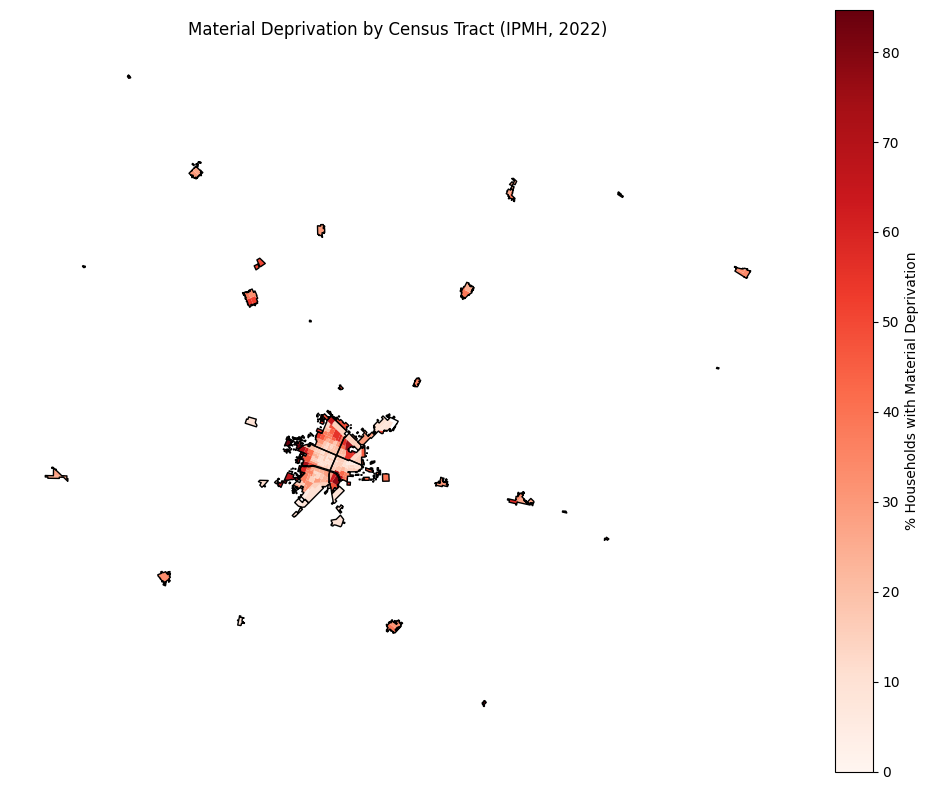

In [23]:
# | code-fold: true
# | code-summary: "Show visualization code"

fig, ax = plt.subplots(figsize=DEFAULT_FIGSIZE)

vulnerability.plot(
    column="pct_privacion",
    ax=ax,
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "% Households with Material Deprivation"},
)

urban_areas.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
ax.set_title("Material Deprivation by Census Tract (IPMH, 2022)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Vulnerable Population in Heat Hotspots

We now overlay vulnerability with exposure to identify who faces the highest risk.

In [24]:
# Rasterize deprivation to match LST grid
vuln_lst_crs = vulnerability.to_crs(LST_max.rio.crs)

vuln_rasterized = features.rasterize(
    [
        (geom, val)
        for geom, val in zip(vuln_lst_crs.geometry, vuln_lst_crs["pct_privacion"])
    ],
    out_shape=LST_max.shape,
    transform=LST_max.rio.transform(),
    fill=np.nan,
    dtype=np.float32,
)

# Define high vulnerability as top quartile
high_vuln_threshold = vulnerability["pct_privacion"].quantile(0.75)
high_vuln_mask = vuln_rasterized > high_vuln_threshold

print(f"High vulnerability threshold (P75): {high_vuln_threshold:.1f}%")

# Population in BOTH hotspots AND high vulnerability areas
pop_high_risk = float(ghsl_aligned.where(hotspot_mask & high_vuln_mask).sum())

print(f"\nHigh-risk population (hotspot + high vulnerability): {pop_high_risk:,.0f}")
print(f"Percentage of total: {(pop_high_risk / total_pop_ghsl) * 100:.1f}%")

High vulnerability threshold (P75): 42.9%

High-risk population (hotspot + high vulnerability): -9,180
Percentage of total: -8.1%


In [25]:
# Inequity analysis: are vulnerable populations disproportionately exposed?
print("=" * 60)
print("INEQUITY ANALYSIS")
print("=" * 60)

for clase in ["urbana", "periurbana", "rural"]:
    subset = urban_areas_lst_crs[urban_areas_lst_crs["clasificacion"] == clase]
    if len(subset) == 0:
        continue

    class_mask = (
        features.rasterize(
            [(geom, 1) for geom in subset.geometry],
            out_shape=LST_max.shape,
            transform=LST_max.rio.transform(),
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    # General population exposure rate
    total_class = float(ghsl_aligned.where(class_mask).sum())
    exposed_class = float(ghsl_aligned.where(hotspot_mask & class_mask).sum())
    general_rate = exposed_class / total_class if total_class > 0 else 0

    # Vulnerable population exposure rate
    # Estimate vulnerable pop using deprivation rate * total pop
    vuln_pop_class = float(
        (ghsl_aligned * (vuln_rasterized / 100)).where(class_mask).sum()
    )
    vuln_exposed = float(
        (ghsl_aligned * (vuln_rasterized / 100)).where(hotspot_mask & class_mask).sum()
    )
    vuln_rate = vuln_exposed / vuln_pop_class if vuln_pop_class > 0 else 0

    ratio = vuln_rate / general_rate if general_rate > 0 else 0

    print(f"\n{clase.upper()}:")
    print(f"  General exposure rate: {general_rate * 100:.1f}%")
    print(f"  Vulnerable exposure rate: {vuln_rate * 100:.1f}%")
    print(f"  Inequity ratio: {ratio:.2f}x")

INEQUITY ANALYSIS

URBANA:
  General exposure rate: 0.0%
  Vulnerable exposure rate: 0.0%
  Inequity ratio: 0.00x

PERIURBANA:
  General exposure rate: 0.0%
  Vulnerable exposure rate: 0.0%
  Inequity ratio: 0.00x


## Risk Summary by Neighborhood

We aggregate our findings by neighborhood to identify priority areas for intervention.

In [26]:
barrios_lst_crs = barrios.to_crs(LST_max.rio.crs)

results = []

for idx, barrio in barrios_lst_crs.iterrows():
    barrio_name = barrio.get("nombre", barrio.get("name", f"Barrio_{idx}"))

    # Total population
    pop_stats = zonal_stats(
        [barrio.geometry],
        ghsl_aligned.squeeze().values,
        affine=ghsl_aligned.rio.transform(),
        stats=["sum"],
        nodata=np.nan,
    )
    total_pop = pop_stats[0]["sum"] or 0

    # Mean LST
    lst_stats = zonal_stats(
        [barrio.geometry],
        LST_max.values,
        affine=LST_max.rio.transform(),
        stats=["mean"],
        nodata=np.nan,
    )
    mean_lst = lst_stats[0]["mean"] or 0

    # Population in hotspots
    hotspot_array = ghsl_aligned.where(hotspot_mask).squeeze().values
    hotspot_stats = zonal_stats(
        [barrio.geometry],
        hotspot_array,
        affine=ghsl_aligned.rio.transform(),
        stats=["sum"],
        nodata=np.nan,
    )
    pop_exposed = hotspot_stats[0]["sum"] or 0

    # Mean deprivation
    vuln_stats = zonal_stats(
        [barrio.geometry],
        vuln_rasterized,
        affine=LST_max.rio.transform(),
        stats=["mean"],
        nodata=np.nan,
    )
    mean_vuln = vuln_stats[0]["mean"] or 0

    results.append(
        {
            "barrio": barrio_name,
            "total_pop": total_pop,
            "mean_lst": mean_lst,
            "pop_exposed": pop_exposed,
            "pct_exposed": (pop_exposed / total_pop * 100) if total_pop > 0 else 0,
            "mean_deprivation": mean_vuln,
        }
    )

barrio_risk = pd.DataFrame(results)
barrio_risk = barrio_risk[barrio_risk["total_pop"] > 100]  # Filter small areas
barrio_risk = barrio_risk.sort_values("pop_exposed", ascending=False)

In [27]:
print("TOP 10 NEIGHBORHOODS BY EXPOSED POPULATION")
print("=" * 70)
print(
    f"{'Neighborhood':<25} {'Pop':>8} {'Exposed':>8} {'%':>6} {'LST':>6} {'Vuln%':>6}"
)
print("-" * 70)

for _, row in barrio_risk.head(10).iterrows():
    print(
        f"{row['barrio'][:24]:<25} "
        f"{row['total_pop']:>8,.0f} "
        f"{row['pop_exposed']:>8,.0f} "
        f"{row['pct_exposed']:>5.1f}% "
        f"{row['mean_lst']:>5.1f}° "
        f"{row['mean_deprivation']:>5.1f}%"
    )

TOP 10 NEIGHBORHOODS BY EXPOSED POPULATION
Neighborhood                   Pop  Exposed      %    LST  Vuln%
----------------------------------------------------------------------
Parque Industrial            6,338       98   1.5%  47.8°   9.1%
Centro                     263,142        0   0.0%  42.3°  13.9%
Trocha                      32,314        0   0.0%  43.3°  14.5%
Villa San José              79,263        0   0.0%  47.2°  37.7%
9 de Julio                  21,969        0   0.0%  46.9°  47.9%
Villa Fernández             30,185        0   0.0%  45.8°  21.1%
Acevedo                    190,083        0   0.0%  45.7°  31.4%
Centenario                  78,216        0   0.0%  43.7°  20.4%
Ameghino                    65,350        0   0.0%  46.0°  20.5%
Martín Illia                56,445        0   0.0%  47.6°  34.4%


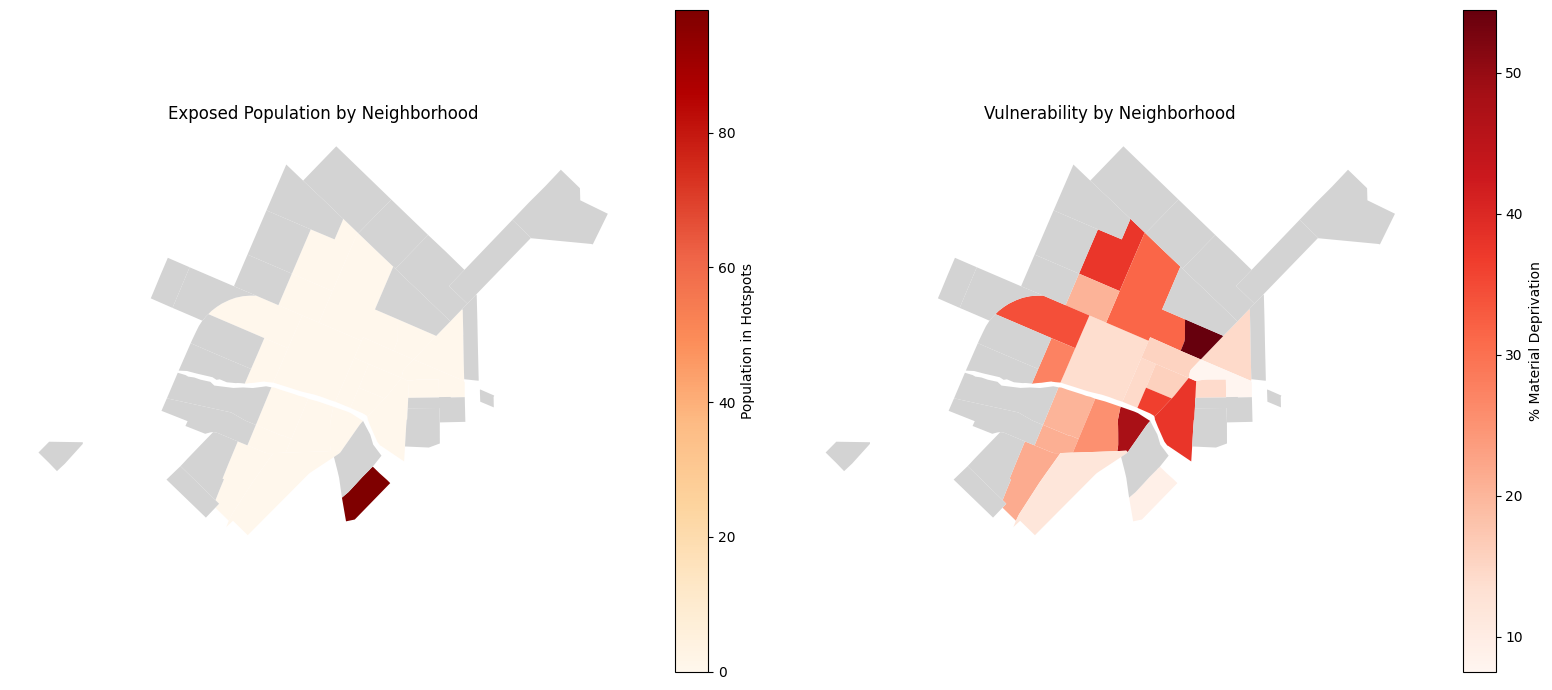

In [28]:
# | code-fold: true
# | code-summary: "Show visualization code"

# Merge risk data back to geodataframe
barrios_risk_gdf = barrios.merge(
    barrio_risk,
    left_on=barrios.columns[
        barrios.columns.str.contains("nombre|name", case=False)
    ].tolist()[0]
    if any(barrios.columns.str.contains("nombre|name", case=False))
    else barrios.index.name,
    right_on="barrio",
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Exposed population
barrios_risk_gdf.plot(
    column="pop_exposed",
    ax=axes[0],
    cmap="OrRd",
    legend=True,
    legend_kwds={"label": "Population in Hotspots"},
    missing_kwds={"color": "lightgray"},
)
axes[0].set_title("Exposed Population by Neighborhood")
axes[0].axis("off")

# Right: Mean deprivation
barrios_risk_gdf.plot(
    column="mean_deprivation",
    ax=axes[1],
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "% Material Deprivation"},
    missing_kwds={"color": "lightgray"},
)
axes[1].set_title("Vulnerability by Neighborhood")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Risk Summary

We compile our findings into a summary of heat risk in Pergamino.

In [29]:
print("=" * 70)
print("EXTREME HEAT RISK SUMMARY: PERGAMINO")
print("=" * 70)

print("\nCLIMATE TRENDS")
print(f"  Historical baseline (1950-2014): {hist_baseline:.1f} days/year >35°C")
print("  Projected 2050 (SSP2-4.5): ~48 days/year (+24%)")
print("  Projected 2070 (SSP2-4.5): ~54 days/year (+40%)")
print("  Projected 2100 (SSP2-4.5): ~59 days/year (+52%)")

print("\nCURRENT HEAT PATTERNS")
print(f"  Hotspot threshold (P75 LST): {hotspot_threshold:.1f}°C")
print("  Hottest areas: Periurban zones")
print("  Coolest areas: Urban core (more trees, more shade)")

print("\nPOPULATION EXPOSURE")
print(f"  Total population (GHSL): {total_pop_ghsl:,.0f}")
print(f"  Total population (Census): {total_pop_census:,}")
print(
    f"  Population in heat hotspots: {float(pop_in_hotspots):,.0f} ({pct_in_hotspots:.1f}%)"
)

print("\nVULNERABILITY")
print(f"  High-risk population (hotspot + high deprivation): {pop_high_risk:,.0f}")
print("  Vulnerable populations are disproportionately exposed")

print("\nPRIORITY NEIGHBORHOODS")
for _, row in barrio_risk.head(3).iterrows():
    print(
        f"  - {row['barrio']}: {row['pop_exposed']:,.0f} exposed ({row['pct_exposed']:.0f}%)"
    )

print("=" * 70)

EXTREME HEAT RISK SUMMARY: PERGAMINO

CLIMATE TRENDS
  Historical baseline (1950-2014): 38.7 days/year >35°C
  Projected 2050 (SSP2-4.5): ~48 days/year (+24%)
  Projected 2070 (SSP2-4.5): ~54 days/year (+40%)
  Projected 2100 (SSP2-4.5): ~59 days/year (+52%)

CURRENT HEAT PATTERNS
  Hotspot threshold (P75 LST): 55.2°C
  Hottest areas: Periurban zones
  Coolest areas: Urban core (more trees, more shade)

POPULATION EXPOSURE
  Total population (GHSL): 113,636
  Total population (Census): 114,472
  Population in heat hotspots: -424,351,402 (-373431.1%)

VULNERABILITY
  High-risk population (hotspot + high deprivation): -9,180
  Vulnerable populations are disproportionately exposed

PRIORITY NEIGHBORHOODS
  - Parque Industrial: 98 exposed (2%)
  - Centro: 0 exposed (0%)
  - Trocha: 0 exposed (0%)


## Recommendations

Based on our analysis, we recommend five interventions. These recommendations follow the principles of robust decision-making: they work across multiple climate scenarios, avoid locking in inflexible approaches, and prioritize equity.

### 1. Emergency Action Plan

**Establish heat emergency protocols with clear activation thresholds.**

- Define temperature thresholds for activating emergency response
- Coordinate protocols across municipal departments
- Map vulnerable populations and cooling refuge locations
- Implement multi-channel early warning system

*Why this is robust:* Emergency protocols are low-cost, highly flexible, and effective across all climate scenarios. They can be revised as conditions change.

### 2. Medium/Long-Term Risk Reduction

**Prioritize interventions in high-exposure, high-vulnerability zones.**

- Focus resources on the neighborhoods identified in our analysis: Martín Illia, Santa Inés, and 12 de Octubre
- Implement comprehensive green and blue infrastructure programs
- Integrate passive cooling into all new public infrastructure
- Use gray infrastructure and non-structural measures where green infrastructure is not viable

*Why this is robust:* Targeting high-risk areas maximizes impact per dollar spent. Green infrastructure provides benefits (shade, air quality, stormwater management) even without climate change.

### 3. Green Infrastructure Program

**Develop a network of green corridors connecting public spaces.**

- Use native species adapted to local conditions
- Prioritize vulnerable neighborhoods
- Follow the Medellín model of green corridors

*Why this is robust:* Green infrastructure is a low-regret investment. It reduces temperatures, improves air quality, manages stormwater, and enhances quality of life regardless of how climate change unfolds.

### 4. Complementary Gray and Non-Structural Measures

**Where green infrastructure isn't viable, use alternatives.**

- Artificial shade structures in industrial zones
- Water features and reflective pavements
- Building codes requiring cool roofs and adequate ventilation
- Adjusted work schedules during heat emergencies

*Why this is robust:* These measures fill gaps where green infrastructure cannot work. They can be implemented incrementally and adjusted as needed.

### 5. Education Initiative

**Communicate the importance of heat risk to the public.**

- Public awareness campaign
- Community ambassador network in priority neighborhoods
- Annual workshops
- Open data publication
- Heat alert dissemination

*Why this is robust:* Public understanding enables individual adaptation and builds political support for municipal action. Education addresses the cognitive biases (the "Ostrich Paradox") that lead to underpreparation for disasters.

---

These recommendations align with the principles from Chapter 4:

1. **Identify possible futures**: We analyzed three climate scenarios (SSP1-2.6, SSP2-4.5, SSP5-8.5)
2. **Explore a range of solutions**: We propose green, gray, and non-structural interventions
3. **Select solutions that work across futures**: All recommendations remain effective whether warming is moderate or severe
4. **Choose flexible implementations**: Emergency protocols, phased infrastructure, and education can all be adapted as conditions evolve

## Conclusion

This analysis demonstrates how to assess extreme heat risk using open data. We combined:

- **Climate projections** (CMIP6) to understand future trends
- **Satellite imagery** (Landsat LST) to identify current hotspots
- **Census and population data** to measure exposure
- **Deprivation indices** to assess vulnerability

The key findings for Pergamino:

- Extreme heat days will increase significantly under all scenarios
- Periurban areas are currently the hottest, while the urban core is cooler
- Approximately 10,500 people live in extreme heat areas
- Vulnerable populations face disproportionate exposure (1.43× in urban areas)
- Priority neighborhoods for intervention: Martín Illia, Santa Inés, 12 de Octubre

### Limitations

This analysis has important limitations:

- **LST ≠ human heat experience**: Land surface temperature indicates relative hotspots but does not directly predict heat stress on people
- **Static vulnerability**: IPMH captures material deprivation but not age, health status, or social networks
- **Model uncertainty**: CMIP6 projections carry substantial uncertainty, especially at local scales
- **No local knowledge**: This analysis should be supplemented with input from municipal officials and residents

### Next Steps

For municipal decision-makers:

1. Validate findings with local knowledge
2. Conduct field surveys in priority neighborhoods
3. Develop heat emergency protocols
4. Begin green infrastructure planning in highest-risk areas

In [30]:
# Cleanup
client.close()
cluster.close()
con.close()